### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [9]:
%pip install ipywidgets

import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# Updated import: YolosImageProcessor replaces the deprecated YolosFeatureExtractor
from transformers import YolosImageProcessor, YolosForObjectDetection, AutoImageProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Note: you may need to restart the kernel to use updated packages.
Using device: cuda



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

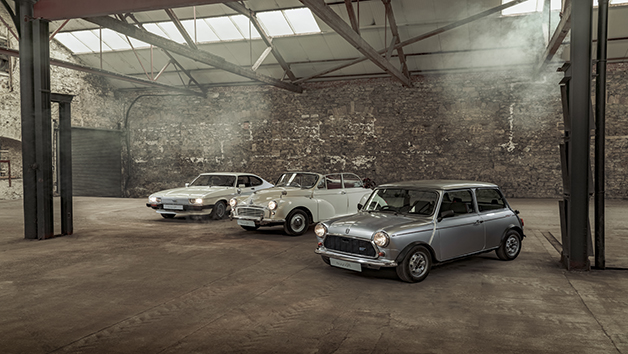

In [11]:
import os
image_path = 'cars.jpg' if os.path.exists('cars.jpg') else 'YOLO/cars.jpg'
image = Image.open(image_path)
image

In [12]:
import torch
from PIL import Image
# Use YolosImageProcessor or AutoImageProcessor
from transformers import YolosImageProcessor, YolosForObjectDetection

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the updated processor and model
image_processor = YolosImageProcessor.from_pretrained('hustvl/yolos-small')
model = YolosForObjectDetection.from_pretrained('hustvl/yolos-small').to(device)

print("Processor and Model loaded successfully on:", device)

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aziz1\.cache\huggingface\hub\models--hustvl--yolos-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 4552.58it/s]


Processor and Model loaded successfully on: cuda


In [14]:
from transformers import YolosImageProcessor, YolosForObjectDetection

# Replace YolosFeatureExtractor with YolosImageProcessor
image_processor = YolosImageProcessor.from_pretrained('hustvl/yolos-small')
model = YolosForObjectDetection.from_pretrained('hustvl/yolos-small').to(device)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 2134.06it/s]


In [15]:
from torchvision.ops import nms

In [21]:
def image_classification(image_path, confidence_threshold=0.8, iou_threshold=0.5):
    image = Image.open(image_path)
    
    # 1. Use image_processor and move input tensors to GPU
    inputs = image_processor(images=image, return_tensors="pt").to(device)

    # 2. Run inference on device
    outputs = model(**inputs)

    # 3. Post-processing with image_processor (must pass target sizes on CPU)
    target_sizes = torch.tensor([image.size[::-1]])
    results = image_processor.post_process_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=confidence_threshold
    )[0]

    # Transfer processed tensors to CPU for NMS and Matplotlib plotting
    scores = results["scores"].cpu()
    labels = results["labels"].cpu()
    boxes = results["boxes"].cpu()

    # Apply Non-Maximum Suppression (NMS)
    keep_indices = nms(boxes, scores, iou_threshold)
    boxes = boxes[keep_indices]
    scores = scores[keep_indices]
    labels = labels[keep_indices]

    # Plot bounding boxes on image
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image)

    for score, label, box in zip(scores, labels, boxes):
        box = [round(i, 2) for i in box.tolist()]
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin

        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        label_text = f"{model.config.id2label[label.item()]}: {round(score.item(), 2)}"
        ax.text(xmin, max(ymin - 10, 0), label_text, color='red', fontsize=9, bbox=dict(facecolor='yellow', alpha=0.5))

    plt.axis('off')
    plt.show()

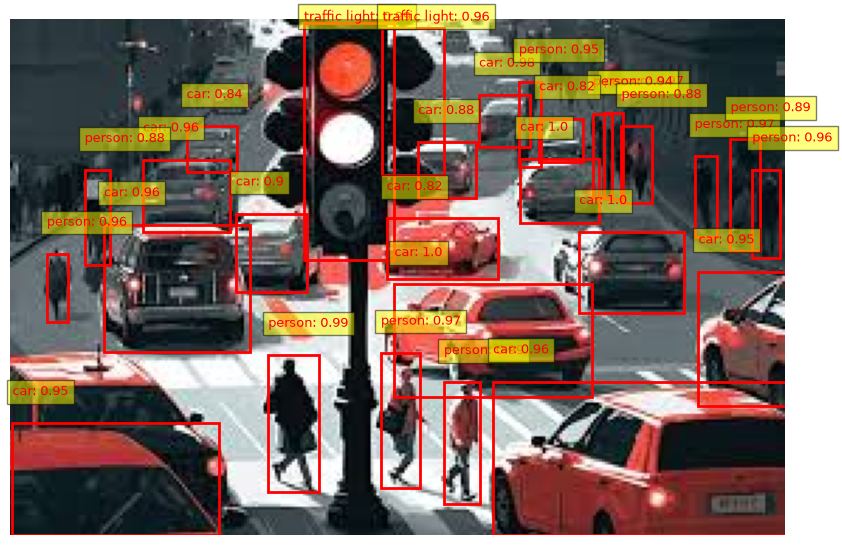

In [22]:
image_classification(image_path)

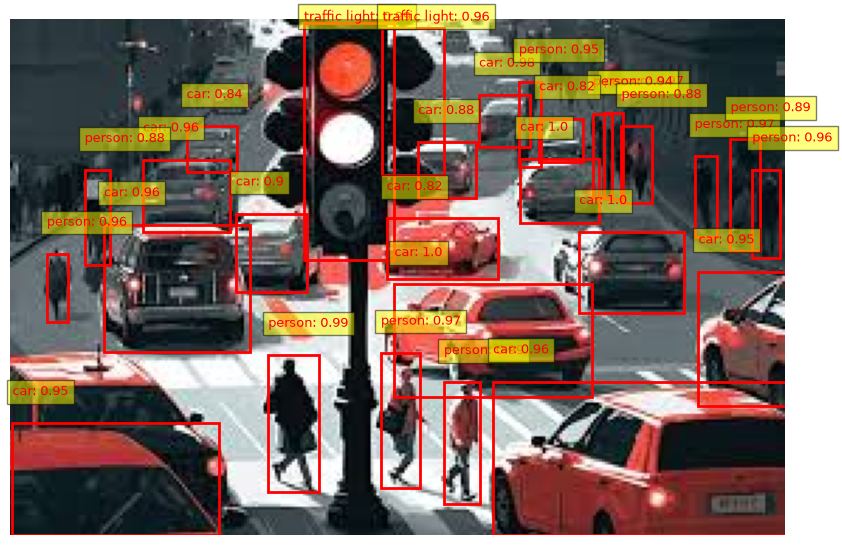

In [23]:
import os
image_path = 'images.jpeg' if os.path.exists('images.jpeg') else 'YOLO/images.jpeg'

image_classification(image_path)

In [20]:
import os
image_path = 'images.jpeg' if os.path.exists('images.jpeg') else 'YOLO/images.jpeg'

image_classification(image_path)

YolosObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[-27.7102,  -4.2507, -13.8120,  ..., -30.6120, -31.1124,  -9.2801],
         [-20.3506,  -5.7540, -12.4826,  ..., -29.7158, -25.6107,  -2.2956],
         [-23.1796,  -6.2218,  -7.5196,  ..., -28.0793, -27.4069,  -6.5432],
         ...,
         [-19.6040,  -4.5100,  -7.6254,  ..., -24.8480, -23.8119,  -2.1194],
         [-18.3760,  -3.2014,  -8.0664,  ..., -22.8403, -21.1200,  -1.8987],
         [-17.3098,  -4.9696,  -8.3482,  ..., -20.3967, -19.5481,  -2.0283]]],
       device='cuda:0', grad_fn=<ViewBackward0>), pred_boxes=tensor([[[0.3641, 0.7809, 0.0654, 0.2649],
         [0.1423, 0.8663, 0.2831, 0.2611],
         [0.7279, 0.4745, 0.0576, 0.1348],
         [0.8181, 0.8517, 0.3462, 0.2894],
         [0.1061, 0.4928, 0.0225, 0.0943],
         [0.1111, 0.3819, 0.0333, 0.1839],
         [0.7060, 0.0970, 0.0409, 0.1363],
         [0.6062, 0.6089, 0.1847, 0.1954],
         [0.8098, 0.7434, 0.3799, 0.5015],
         [0.4